# Scratch Work: FGA Model with Convergence Diagnostics

This notebook demonstrates fitting an FGA (Fixed Growth Advantage) model to the tropics deme using the 2028-10-01 dataset, with a focus on extracting convergence diagnostics.

In [2]:
# Import necessary libraries
import sys
sys.path.append('..')
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# JAX and NumPyro imports
import jax
import jax.numpy as jnp
import numpyro
import numpyro.diagnostics as diagnostics

# evofr imports
import evofr as ef

from antigentools import utils, plot

# Set random seed for reproducibility
np.random.seed(42)
numpyro.set_platform('cpu')

## 1. Load and Prepare Data

In [3]:
# Define data paths
data_date = "2028-10-01"
data_path = f"../data/flu-simulated-150k-samples/time-stamped/{data_date}/"
country = "tropics"

# Load sequence counts
seq_counts = pd.read_csv(data_path + "seq_counts.tsv", sep='\t')
seq_counts = seq_counts[seq_counts['country'] == country]

# Load case counts
case_counts = pd.read_csv(data_path + "case_counts.tsv", sep='\t')
case_counts = case_counts[case_counts['country'] == country]

print(f"Loaded data for {country} from {data_date}")
print(f"Sequence counts shape: {seq_counts.shape}")
print(f"Case counts shape: {case_counts.shape}")
print(f"Date range: {seq_counts['date'].min()} to {seq_counts['date'].max()}")
print(f"Number of variants: {seq_counts['variant'].nunique()}")
print(f"Variants: {sorted(seq_counts['variant'].unique())}")

Loaded data for tropics from 2028-10-01
Sequence counts shape: (186, 4)
Case counts shape: (52, 3)
Date range: 2027-10-03 to 2028-10-01
Number of variants: 5
Variants: [5, 12, 16, 20, 27]


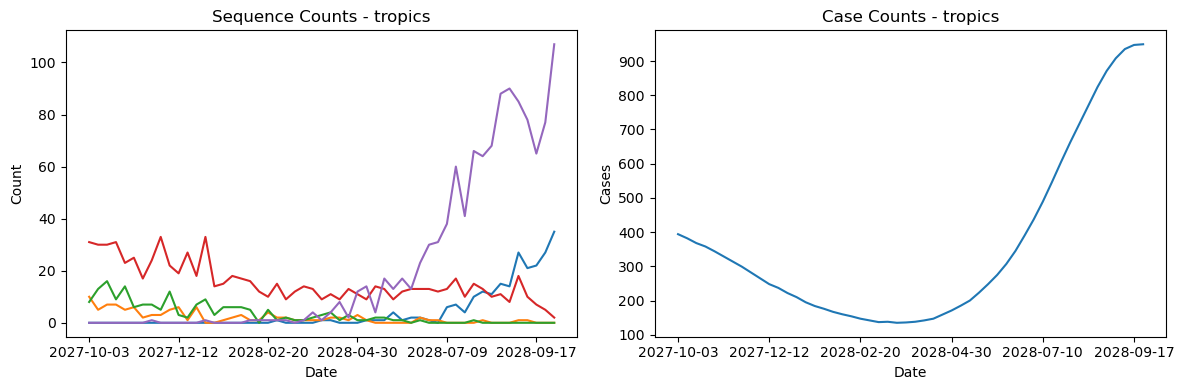

In [4]:
# Quick visualization of the data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot sequence counts over time
seq_pivot = seq_counts.pivot_table(index='date', columns='variant', values='sequences', fill_value=0)
seq_pivot.plot(ax=ax1, legend=False)
ax1.set_title(f'Sequence Counts - {country}')
ax1.set_xlabel('Date')
ax1.set_ylabel('Count')

# Plot case counts over time
case_counts.plot(x='date', y='cases', ax=ax2, legend=False)
ax2.set_title(f'Case Counts - {country}')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cases')

plt.tight_layout()
plt.show()

## 2. Create Variant Frequency Data

In [5]:
# Get variant names
v_names = sorted(seq_counts['variant'].unique().tolist())
print(f"Variants to model: {v_names}")

# Create CaseFrequencyData object
variant_data = ef.CaseFrequencyData(
    raw_seq=seq_counts, 
    raw_cases=case_counts, 
    var_names=v_names
)

print(f"\nVariant data created:")
print(f"  Number of time points: {len(variant_data.dates)}")
print(f"  Number of variants: {len(variant_data.var_names)}")
print(f"  Sequence counts shape: {variant_data.seq_counts.shape}")
print(f"  Case counts shape: {variant_data.cases.shape}")

Variants to model: [5, 12, 16, 20, 27]

Variant data created:
  Number of time points: 365
  Number of variants: 5
  Sequence counts shape: (365, 5)
  Case counts shape: (365,)


## 3. Set up FGA Model

In [6]:
# Model parameters
seed_L = 14  # Seed length (days)
forecast_L = 180  # Forecast length (days)

# Define generation time distributions for each variant
gen = ef.pad_delays(
    [ef.discretise_gamma(mn=3.0, std=1.2) for _ in v_names]
)

# Define delay distribution (from infection to case report)
delays = ef.pad_delays([ef.discretise_lognorm(mn=3.1, std=1.0)])

# Define basis function for smoothing
basis_fn = ef.Spline(order=4, k=10)

# Create FGA model
model = ef.RenewalModel(
    gen, 
    delays, 
    seed_L=seed_L, 
    forecast_L=forecast_L,
    RLik=ef.FixedGA(0.1),  # Fixed Growth Advantage likelihood
    CLik=ef.ZINegBinomCases(0.05),  # Zero-inflated negative binomial for cases
    SLik=ef.DirMultinomialSeq(100),  # Dirichlet-multinomial for sequences
    v_names=v_names,
    basis_fn=basis_fn
)

print("FGA model created successfully")

FGA model created successfully


## 4. Fit Model with Enhanced Inference Settings

In [8]:
# Define inference method with more iterations for better convergence
inference_method = ef.InferFullRank(
    iters=100_000,  # Increased iterations
    lr=0.01,
    num_samples=1000  # More samples for better diagnostics
)

print("Starting model fitting...")

# Fit the model
try:
    posterior = inference_method.fit(model, variant_data)
    print("Model fitting completed successfully!")
except Exception as e:
    print(f"Error during model fitting: {e}")
    raise

Starting model fitting...
Model fitting completed successfully!


## 5. Extract and Analyze Convergence Diagnostics

## 5b. VI Convergence Diagnostics (ELBO-based)

Since evofr uses variational inference rather than MCMC, we need different convergence diagnostics. We'll use the ELBO trajectory to assess convergence.

In [14]:
# Function to compute VI convergence diagnostics
def compute_vi_convergence_diagnostics(posterior, window=100, threshold=1e-2):
    """
    Compute convergence diagnostics for variational inference.
    
    Parameters
    ----------
    posterior : PosteriorHandler
        Posterior object from evofr containing samples and losses
    window : int
        Number of iterations to use for computing relative change
    threshold : float
        Threshold for relative change to consider converged
        
    Returns
    -------
    dict
        Dictionary containing convergence diagnostics
    """
    diagnostics_results = {}
    
    # Extract ELBO losses (negative ELBO values)
    if 'losses' in posterior.samples:
        losses = posterior.samples['losses']
        
        # Convert to numpy array if needed
        if hasattr(losses, 'numpy'):
            losses = losses.numpy()
        
        # Basic statistics
        diagnostics_results['elbo_trajectory'] = {
            'num_iterations': len(losses),
            'initial_loss': float(losses[0]),
            'final_loss': float(losses[-1]),
            'min_loss': float(np.min(losses)),
            'total_improvement': float(losses[0] - losses[-1])
        }
        
        # Convergence check using relative change
        if len(losses) >= window:
            relative_change = abs(losses[-1] - losses[-window]) / abs(losses[-window])
            converged = relative_change < threshold
            
            diagnostics_results['convergence'] = {
                'converged': bool(converged),
                'relative_change': float(relative_change),
                'threshold': threshold,
                'window': window,
                'final_iteration': len(losses)
            }
        else:
            diagnostics_results['convergence'] = {
                'converged': False,
                'message': f'Not enough iterations ({len(losses)}) for window size ({window})'
            }
    else:
        diagnostics_results['error'] = 'No losses found in posterior.samples'
    
    return diagnostics_results

In [16]:
# Test convergence across multiple window sizes
windows_to_test = [50, 100, 200, 500, 1000]
threshold = 1e-2

# Dictionary to hold results from window testing
window_test_results = {}

# Compute diagnostics for each window
for window in windows_to_test:
    window_test_results[window] = compute_vi_convergence_diagnostics(posterior, window=window, threshold=threshold)

# Print all diagnostics
print("=== VI CONVERGENCE DIAGNOSTICS ===")

# Print ELBO trajectory (same for all windows)
print("\nELBO Trajectory:")
if 'elbo_trajectory' in window_test_results[windows_to_test[0]]:
    for key, value in window_test_results[windows_to_test[0]]['elbo_trajectory'].items():
        print(f"  {key}: {value}")

# Print convergence results for each window
print(f"\nConvergence Analysis (threshold = {threshold}):")
print(f"{'Window':>10} | {'Converged':>10} | {'Relative Change':>15}")
print("-" * 40)

for window in windows_to_test:
    result = window_test_results[window]
    if 'convergence' in result and 'converged' in result['convergence']:
        converged = result['convergence']['converged']
        rel_change = result['convergence']['relative_change']
        print(f"{window:>10} | {'Yes' if converged else 'No':>10} | {rel_change:>15.6f}")
    else:
        print(f"{window:>10} | {'N/A':>10} | {'N/A':>15}")

# Summary
print("\nSummary:")
converged_windows = [w for w in windows_to_test 
                     if window_test_results[w].get('convergence', {}).get('converged', False)]
if converged_windows:
    print(f"  Model converged for windows: {converged_windows}")
    print(f"  Smallest window with convergence: {min(converged_windows)}")
else:
    print("  Model did not converge for any tested window size")

=== VI CONVERGENCE DIAGNOSTICS ===

ELBO Trajectory:
  num_iterations: 100000
  initial_loss: 501798.6875
  final_loss: 1069.73486328125
  min_loss: 1056.343017578125
  total_improvement: 500728.9375

Convergence Analysis (threshold = 0.01):
    Window |  Converged | Relative Change
----------------------------------------
        50 |        Yes |        0.002969
       100 |        Yes |        0.001552
       200 |        Yes |        0.006046
       500 |        Yes |        0.002594
      1000 |        Yes |        0.008853

Summary:
  Model converged for windows: [50, 100, 200, 500, 1000]
  Smallest window with convergence: 50


## 6. Visualize Results

In [ ]:
# Extract posterior frequencies
ps = [0.95, 0.8, 0.5]  # Quantiles

# Get nowcast frequencies
freq_nowcast = pd.DataFrame(ef.get_freq(posterior.samples, variant_data, ps, name=country, forecast=False))

# Get forecast frequencies
freq_forecast = pd.DataFrame(ef.get_freq(posterior.samples, variant_data, ps, name=country, forecast=True))

# Plot posterior frequencies
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variant
for variant in v_names:
    # Nowcast
    variant_nowcast = freq_nowcast[freq_nowcast['variant'] == variant]
    ax.plot(pd.to_datetime(variant_nowcast['date']), 
            variant_nowcast['median_freq'], 
            label=f'Variant {variant}', 
            linewidth=2)
    
    # Forecast
    variant_forecast = freq_forecast[freq_forecast['variant'] == variant]
    ax.plot(pd.to_datetime(variant_forecast['date']), 
            variant_forecast['median_freq'], 
            '--', 
            alpha=0.7)

# Add vertical line at analysis date
ax.axvline(pd.to_datetime(data_date), color='red', linestyle='--', alpha=0.5, label='Analysis date')

ax.set_xlabel('Date')
ax.set_ylabel('Frequency')
ax.set_title(f'FGA Model: Variant Frequencies in {country}')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. Next Steps

This notebook demonstrates how to:
1. Fit an FGA model using evofr
2. Extract convergence diagnostics (R-hat and ESS)
3. Save diagnostics to a JSON file
4. Visualize results and assess convergence

The convergence diagnostic extraction code can be integrated into `run_model.py` to automatically log these statistics for all model runs.